### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

### Load dataset

In [2]:
data = pd.read_csv("../data/titanic_clean.csv")
X = data.drop("Survived", axis=1)
y = data["Survived"]

### Load trained models

In [3]:
rf = joblib.load("../models/random_forest_model.pkl")
gb = joblib.load("../models/gradient_boosting_model.pkl")

In [4]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone']


### Evaluate models

In [5]:
y_pred_rf = rf.predict(X)
y_prob_rf = rf.predict_proba(X)[:,1]

y_pred_gb = gb.predict(X)
y_prob_gb = gb.predict_proba(X)[:,1]

results = {
    "Random Forest": {
        "Accuracy": accuracy_score(y, y_pred_rf),
        "Precision": precision_score(y, y_pred_rf),
        "Recall": recall_score(y, y_pred_rf),
        "F1": f1_score(y, y_pred_rf),
        "ROC-AUC": roc_auc_score(y, y_prob_rf)
    },
    "Gradient Boosting": {
        "Accuracy": accuracy_score(y, y_pred_gb),
        "Precision": precision_score(y, y_pred_gb),
        "Recall": recall_score(y, y_pred_gb),
        "F1": f1_score(y, y_pred_gb),
        "ROC-AUC": roc_auc_score(y, y_prob_gb)
    }
}
print(pd.DataFrame(results).T)

                   Accuracy  Precision    Recall        F1   ROC-AUC
Random Forest      0.921437   0.944444  0.845029  0.891975  0.965357
Gradient Boosting  0.911336   0.925566  0.836257  0.878648  0.950700


### Plot ROC curves

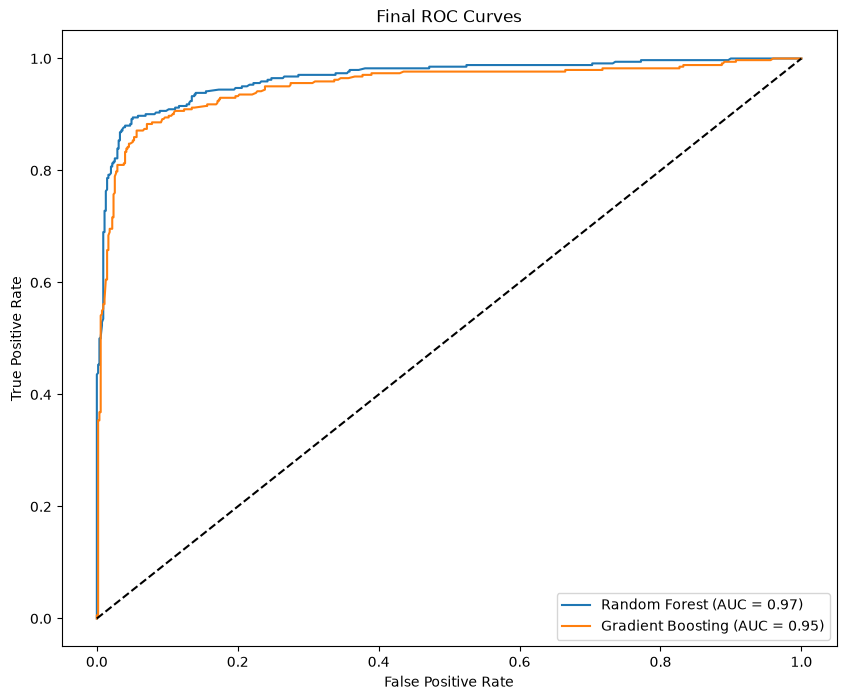

In [6]:
plt.figure(figsize=(10,8))
fpr_rf, tpr_rf, _ = roc_curve(y, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y, y_prob_gb)

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {results['Random Forest']['ROC-AUC']:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {results['Gradient Boosting']['ROC-AUC']:.2f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curves")
plt.legend()
plt.show()

### Prediction

In [7]:
model = joblib.load("../models/random_forest_model.pkl")

# Take one sample from test set
sample = X.iloc[[0]] 

# Predict
prediction = model.predict(sample)
print("Prediction:", prediction)

Prediction: [0]
